In [360]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load and filter data
df = pd.read_csv('house_prices.csv')
print("Initial rows:", len(df))

# Drop invalid prices
df = df[df['price'].notna() & (df['price'] > 0)]
print("Rows after price filter:", len(df))

# Handle missing values
print("Missing values:\n", df[['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'bathrooms']].isna().sum())
df.fillna({
    'bedrooms': df['bedrooms'].mode()[0],  # Mode for discrete
    'bathrooms': df['bathrooms'].mode()[0],
    'sqft_living': df['sqft_living'].mean(),
    'sqft_lot': df['sqft_lot'].mean(),
    'sqft_above': df['sqft_above'].mean()
}, inplace=True)

# Remove price outliers
df = df[df['price'] < df['price'].quantile(0.99)]
print("Rows after outlier removal:", len(df))

# Optional: Comment out bedroom filter unless required
# mask = df['bedrooms'].isin([3, 4, 5])
# filtered_df = df[mask]
# print("Rows after bedroom filter:", len(filtered_df))
filtered_df = df  # Keep all data for now


Initial rows: 4140
Rows after price filter: 4091
Missing values:
 bedrooms       0
sqft_living    0
sqft_lot       0
sqft_above     0
bathrooms      0
dtype: int64
Rows after outlier removal: 4050


In [361]:
# Features and target
features = ['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'bathrooms']
X = filtered_df[features]
y = filtered_df['price']
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



In [362]:
# Train model
lr_model = LinearRegression() #Multi Feature Predictions Model
lr_model.fit(X_train, y_train)
print(f"Model R² Score: {lr_model.score(X_test, y_test):.2f}")

Model R² Score: 0.49


In [363]:
# Predict and evaluate Linear Regression Model Multi Feature 
lr_y_pred = lr_model.predict(X_test)
print(f"First 5 predictions: {lr_y_pred[:5]}")
print(f"First 5 actual prices: {y_test.values[:5]}")
lr_errors = y_test.values - lr_y_pred
print(f"First 5 prediction errors: {lr_errors[:5]}")
print(f"Mean Absolute Error: {np.mean(np.abs(lr_errors)):.1f}")



First 5 predictions: [ 498399.61685887 1140895.29446632  743230.5730553   438751.49839288
  652226.79554674]
First 5 actual prices: [ 386000. 1680000.  718500.  335000.  383962.]
First 5 prediction errors: [-112399.61685887  539104.70553368  -24730.5730553  -103751.49839288
 -268264.79554674]
Mean Absolute Error: 151043.8


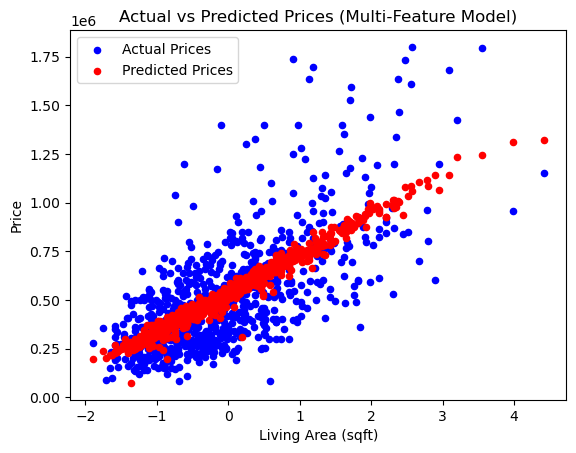

In [364]:
# Visualize predictions Multi-Feature (using sqft_living for x-axis)
# Convert X_test back to DataFrame with original (unscaled) values

lr_plot_df = pd.DataFrame({
    'sqft_living': X_test[:, 1],           # NumPy array
    'actual_price': y_test.values,         # Convert Series to NumPy
    'predicted_price': lr_y_pred           # Already NumPy
})
lr_ax = lr_plot_df.plot(kind='scatter', x='sqft_living', y='actual_price', color='blue', label='Actual Prices')
lr_plot_df.plot(kind='scatter', x='sqft_living', y='predicted_price', color='red', label='Predicted Prices', ax=lr_ax)
lr_ax.set_xlabel('Living Area (sqft)')
lr_ax.set_ylabel('Price')
lr_ax.set_title('Actual vs Predicted Prices (Multi-Feature Model)')
plt.savefig('multi_feature_predictions.png')
plt.show()



In [365]:
# Check correlation to optimize features
print(filtered_df[['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'bathrooms']].corr())

             bedrooms  sqft_living  sqft_lot  sqft_above  bathrooms
bedrooms     1.000000     0.596054  0.066467    0.472424   0.540552
sqft_living  0.596054     1.000000  0.201402    0.866463   0.742212
sqft_lot     0.066467     0.201402  1.000000    0.207283   0.095557
sqft_above   0.472424     0.866463  0.207283    1.000000   0.668792
bathrooms    0.540552     0.742212  0.095557    0.668792   1.000000


In [366]:
# Train model Decision Tree Regressor
dtr_model = DecisionTreeRegressor(random_state=42) #Decision Tree Prediction Model
dtr_model.fit(X_train, y_train)
print(f"Decision Tree R² Score: {dtr_model.score(X_test, y_test):.2f}")


Decision Tree R² Score: 0.07


In [367]:
#Predict and evaluate Decision Tree Regressor
dtr_y_pred = dtr_model.predict(X_test)
print(f"First 5 predictions: {dtr_y_pred[:5]}")
print(f"First 5 actual prices: {y_test.values[:5]}")
dtr_errors = y_test.values - dtr_y_pred
print(f"First 5 prediction errors: {dtr_errors[:5]}")
print(f"Mean Absolute Error: {np.mean(np.abs(dtr_errors)):.1f}")

First 5 predictions: [550000. 831500. 994500. 356000. 651000.]
First 5 actual prices: [ 386000. 1680000.  718500.  335000.  383962.]
First 5 prediction errors: [-164000.  848500. -276000.  -21000. -267038.]
Mean Absolute Error: 198127.7


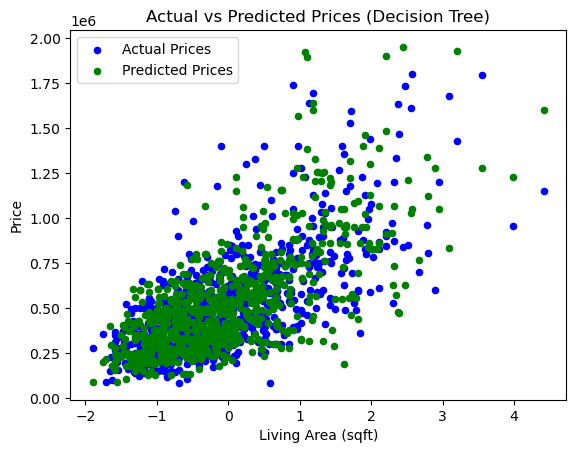

In [368]:
# Visualize predictions Decision Tree (using sqft_living for x-axis) 
dtr_plot_df = pd.DataFrame({
        'sqft_living': X_test[:, 1],            # NumPy array
        'actual_price': y_test.values,          # Convert Series to NumPy
        'predicted_price': dtr_y_pred           # Already NumPy
})
dtr_ax = dtr_plot_df.plot(kind='scatter', x='sqft_living', y='actual_price', color='blue', label='Actual Prices')
dtr_plot_df.plot(kind='scatter', x='sqft_living', y='predicted_price', color='green', label='Predicted Prices', ax=dtr_ax)
dtr_ax.set_xlabel('Living Area (sqft)')
dtr_ax.set_ylabel('Price')
dtr_ax.set_title('Actual vs Predicted Prices (Decision Tree)')
plt.savefig('decision_tree_predictions.png')
plt.show()

In [369]:
# Scale features (important for KNN)
knn_scaler = StandardScaler()
X_train_scaled = knn_scaler.fit_transform(X_train)
X_test_scaled = knn_scaler.transform(X_test)

In [370]:
# Train KNN model
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
print(f"KNN R² Score: {knn_model.score(X_test_scaled, y_test):.2f}")

KNN R² Score: 0.40


In [371]:
# Predict and evaluate
knn_y_pred = knn_model.predict(X_test_scaled)
print(f"First 5 predictions: {knn_y_pred[:5]}")
print(f"First 5 actual prices: {y_test.values[:5]}")
knn_errors = y_test.values - knn_y_pred
print(f"First 5 prediction errors: {knn_errors[:5]}")
print(f"Mean Absolute Error: {np.mean(np.abs(knn_errors)):.1f}")

First 5 predictions: [ 387550. 1333000.  961000.  516200.  507300.]
First 5 actual prices: [ 386000. 1680000.  718500.  335000.  383962.]
First 5 prediction errors: [  -1550.  347000. -242500. -181200. -123338.]
Mean Absolute Error: 160799.8


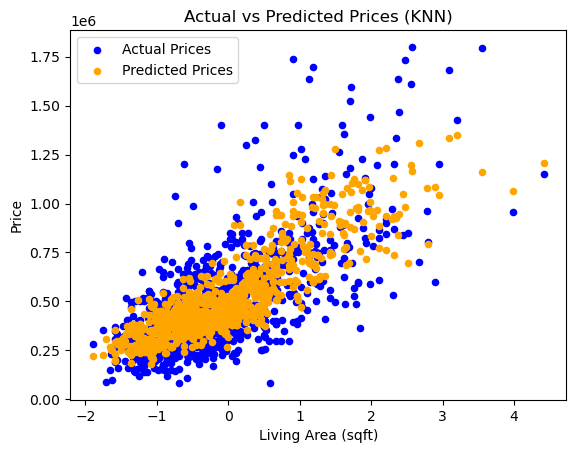

In [372]:
# Visualize predictions (using sqft_living for x-axis)
knn_plot_df = pd.DataFrame({
        'sqft_living': X_test[:, 1],            # NumPy array
        'actual_price': y_test.values,           # Convert Series to NumPy
        'predicted_price': knn_y_pred           # Already NumPy
     })
knn_ax = knn_plot_df.plot(kind='scatter', x='sqft_living', y='actual_price', color='blue', label='Actual Prices')
knn_plot_df.plot(kind='scatter', x='sqft_living', y='predicted_price', color='orange', label='Predicted Prices', ax=knn_ax)
knn_ax.set_xlabel('Living Area (sqft)')
knn_ax.set_ylabel('Price')
knn_ax.set_title('Actual vs Predicted Prices (KNN)')
plt.savefig('knn_predictions.png')
plt.show()

In [373]:
# Compare model performance
print("\nModel Performance Comparison:")
print(f"Linear Regression R²: {lr_model.score(X_test, y_test):.2f}, MAE: {np.mean(np.abs(lr_errors)):.1f}")
print(f"Decision Tree R²: {dtr_model.score(X_test, y_test):.2f}, MAE: {np.mean(np.abs(dtr_errors)):.1f}")
print(f"KNN R²: {knn_model.score(X_test_scaled, y_test):.2f}, MAE: {np.mean(np.abs(knn_errors)):.1f}")


Model Performance Comparison:
Linear Regression R²: 0.49, MAE: 151043.8
Decision Tree R²: 0.07, MAE: 198127.7
KNN R²: 0.40, MAE: 160799.8


In [374]:
# Calculate feature importance
features = ['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'bathrooms']
importance = dtr_model.feature_importances_
feature_importance = pd.DataFrame({'Feature': features, 'Importance': importance})
print("\nFeature Importance:")
print(feature_importance.sort_values(by='Importance', ascending=False))

  


Feature Importance:
       Feature  Importance
1  sqft_living    0.576453
2     sqft_lot    0.181094
3   sqft_above    0.138556
4    bathrooms    0.059997
0     bedrooms    0.043899


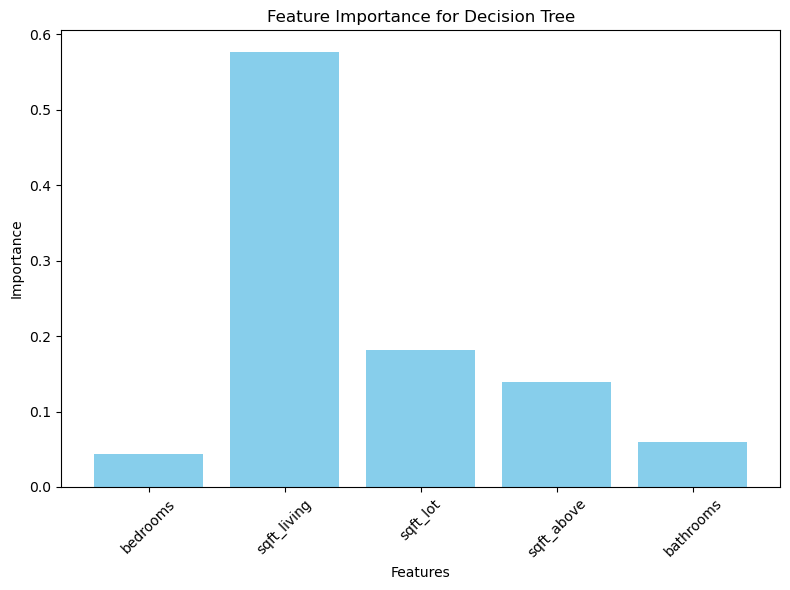

In [375]:
# Visualize feature importance
plt.figure(figsize=(8, 6))
plt.bar(feature_importance['Feature'], feature_importance['Importance'], color='skyblue')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance for Decision Tree')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()


In [376]:
# Example: Exclude low-importance feature (e.g., bedrooms )
exclude_bedrooms_features = ['sqft_lot', 'sqft_living', 'sqft_above', 'bathrooms']  # Adjust based on output
X = filtered_df[exclude_bedrooms_features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
xbedroomsdtr_model = DecisionTreeRegressor(random_state=42)
xbedroomsdtr_model.fit(X_train, y_train)
print(f"Refined Decision Tree R² Score: {xbedroomsdtr_model.score(X_test, y_test):.2f}")
xbedroomsdtr_y_pred = xbedroomsdtr_model.predict(X_test)
xbedroomsdtr_errors = y_test.values - xbedroomsdtr_y_pred 
print(f"Refined MAE: {np.mean(np.abs(xbedroomsdtr_errors)):.1f}")

Refined Decision Tree R² Score: -0.01
Refined MAE: 205034.7


In [377]:
# Define parameter grid for decision tree
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [378]:
# Grid search with cross-validation
grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42),
             param_grid={'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='r2')

In [379]:
# Best model
best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV R² Score: {grid_search.best_score_:.2f}")


Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best CV R² Score: 0.45


In [380]:
# Evaluate on test set
best_y_pred = best_model.predict(X_test)
best_test_r2 = best_model.score(X_test, y_test)
print(f"Test R² Score with Best Model: {best_test_r2:.2f}")
best_errors = y_test.values - best_y_pred
print(f"Test MAE with Best Model: {np.mean(np.abs(best_errors)):.1f}")

Test R² Score with Best Model: 0.46
Test MAE with Best Model: 152312.1


In [381]:
# Define parameter grid for KNN
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # Manhattan (1) or Euclidean (2) distance
        }
   

In [382]:
# Grid search with cross-validation
knn_grid_search = GridSearchCV(KNeighborsRegressor(), knn_param_grid, cv=5, scoring='r2')
knn_grid_search.fit(X_train_scaled, y_train)


GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'n_neighbors': [3, 5, 7, 9, 11], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='r2')

In [383]:
# Best model
knn_best_model = knn_grid_search.best_estimator_
print(f"Best Parameters: {knn_grid_search.best_params_}")
print(f"Best CV R² Score: {knn_grid_search.best_score_:.2f}")


Best Parameters: {'n_neighbors': 11, 'p': 1, 'weights': 'uniform'}
Best CV R² Score: 0.45


In [384]:
# Evaluate on test set
knn_y_pred = knn_best_model.predict(X_test_scaled)
knn_test_r2 = knn_best_model.score(X_test_scaled, y_test)
print(f"Test R² Score with Best Model: {knn_test_r2:.2f}")
knn_errors = y_test.values - knn_y_pred
print(f"Test MAE with Best Model: {np.mean(np.abs(knn_errors)):.1f}")

Test R² Score with Best Model: 0.47
Test MAE with Best Model: 151851.4


In [385]:
 # Features and target
features = ['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'bathrooms']
X = filtered_df[features]
y = filtered_df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [386]:
# Train Random Forest
rfr_model = RandomForestRegressor(random_state=42, n_estimators=100)
rfr_model.fit(X_train, y_train)
print(f"Random Forest R² Score: {rfr_model.score(X_test, y_test):.2f}")

    

Random Forest R² Score: 0.48


In [387]:
# Predict and evaluate
rfr_y_pred = rfr_model.predict(X_test)
print(f"First 5 predictions: {rfr_y_pred[:5]}")
print(f"First 5 actual prices: {y_test.values[:5]}")
rfr_errors = y_test.values - rfr_y_pred
print(f"First 5 prediction errors: {rfr_errors[:5]}")
print(f"Mean Absolute Error: {np.mean(np.abs(rfr_errors)):.1f}")

     

First 5 predictions: [ 601336.35714286 1101629.96        844602.9         391960.5
  556301.45      ]
First 5 actual prices: [ 386000. 1680000.  718500.  335000.  383962.]
First 5 prediction errors: [-215336.35714286  578370.04       -126102.9         -56960.5
 -172339.45      ]
Mean Absolute Error: 150244.4


In [388]:
# Feature importance Random Forest
rfr_importance = rfr_model.feature_importances_
rfr_feature_importance = pd.DataFrame({'Feature': features, 'Importance': importance})
print("\nFeature Importance:")
print(rfr_feature_importance.sort_values(by='Importance', ascending=False))


Feature Importance:
       Feature  Importance
1  sqft_living    0.576453
2     sqft_lot    0.181094
3   sqft_above    0.138556
4    bathrooms    0.059997
0     bedrooms    0.043899


In [389]:
# rfr_model is your trained RandomForestRegressor and rfr_y_pred = rfr_model.predict(X_test)
mse = mean_squared_error(y_test, rfr_y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rfr_y_pred)
print(f"Random Forest - MSE: {mse:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}")

Random Forest - MSE: 43112995446.07, RMSE: 207636.69, R²: 0.48


In [390]:
rfr_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
rfr = RandomForestRegressor(random_state=42)
rfr_grid_search = GridSearchCV(rfr, rfr_param_grid, cv=5, scoring='neg_mean_squared_error')
rfr_grid_search.fit(X_train, y_train)
print("Best parameters:", rfr_grid_search.best_params_)



Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [391]:
# Retrain with best params
rfr_best = rfr_grid_search.best_estimator_
rfr_y_pred_best = rfr_best.predict(X_test)
rfr_mse_best = mean_squared_error(y_test, rfr_y_pred_best)
rfr_rmse_best = np.sqrt(rfr_mse_best)
rfr_r2_best = r2_score(y_test, rfr_y_pred_best)
print(f"Optimized Random Forest - MSE: {rfr_mse_best:.2f}, RMSE: {rfr_rmse_best:.2f}, R²: {rfr_r2_best:.2f}")

Optimized Random Forest - MSE: 41426146829.27, RMSE: 203534.14, R²: 0.50


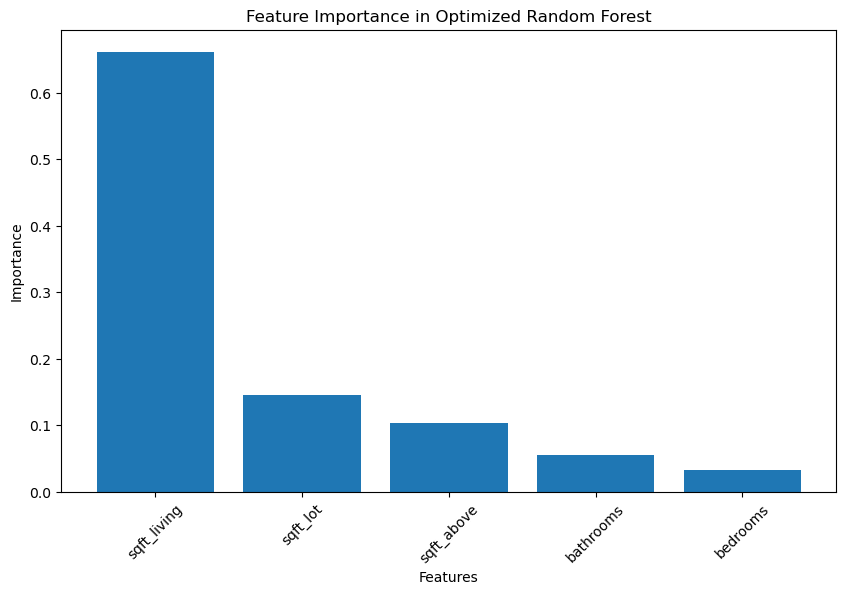

In [392]:
rfr_importances = rfr_best.feature_importances_
rfr_feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': rfr_feature_names, 'Importance': rfr_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Importance'])
plt.xticks(rotation=45)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance in Optimized Random Forest')
plt.savefig('random_forest_feature_importance.png')
plt.show()


In [393]:
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.2]
}
xgb = XGBRegressor(random_state=42)
grid_search_xgb = GridSearchCV(xgb, xgb_param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search_xgb.fit(X_train, y_train)
print("Best XGBoost parameters:", grid_search_xgb.best_params_)

Best XGBoost parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300}


In [394]:
# Train XGBoost
xgb_best = grid_search_xgb.best_estimator_
xgb_y_pred_best = xgb_best.predict(X_test)



In [395]:
# Evaluate
xgb_mse_best = mean_squared_error(y_test, xgb_y_pred_best)
xgb_rmse_best = np.sqrt(xgb_mse_best)
xgb_r2_best = r2_score(y_test, xgb_y_pred_best)

print(f"XGBoost - MSE: {xgb_mse_best:.2f}, RMSE: {xgb_rmse_best:.2f}, R²: {xgb_r2_best:.2f}")

XGBoost - MSE: 39452787146.55, RMSE: 198627.26, R²: 0.52


In [396]:
# Comparison table
results_rfr_xgb = pd.DataFrame({
    'Model': ['Random Forest (Optimized)', 'XGBoost'],
    'MSE': [rfr_mse_best, xgb_mse_best],
    'RMSE': [rfr_rmse_best, xgb_rmse_best],
    'R²': [rfr_r2_best, xgb_r2_best]
})
print(results_rfr_xgb)

                       Model           MSE           RMSE        R²
0  Random Forest (Optimized)  4.142615e+10  203534.141680  0.496866
1                    XGBoost  3.945279e+10  198627.256807  0.520833


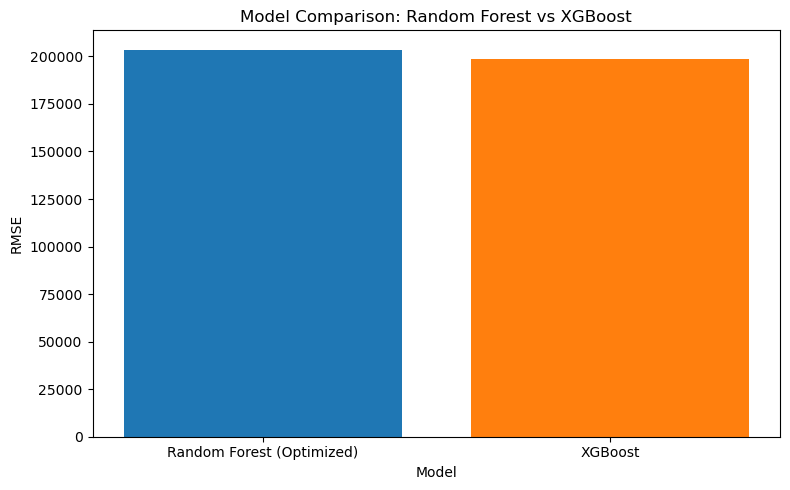

In [397]:
# Bar chart for RMSE
plt.figure(figsize=(8, 5))
plt.bar(results_rfr_xgb['Model'], results_rfr_xgb['RMSE'], color=['#1f77b4', '#ff7f0e'])  # Blue, orange for visibility
plt.xlabel('Model')
plt.ylabel('RMSE')

plt.title('Model Comparison: Random Forest vs XGBoost')
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()


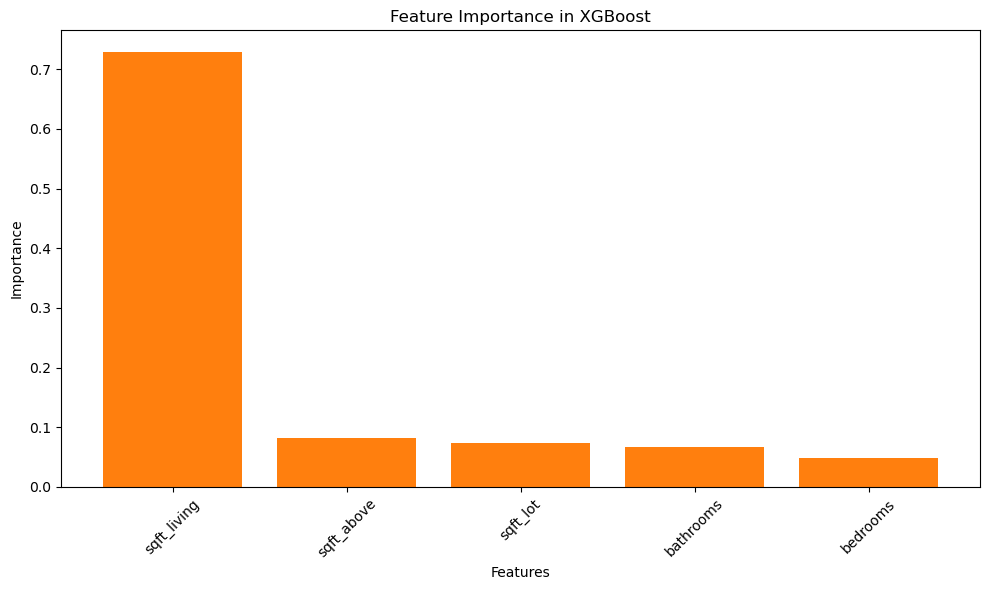

In [398]:
xgb = XGBRegressor(random_state=42,max_depth= 5, n_estimators=300, learning_rate=0.01)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
xgb_importances = xgb.feature_importances_
xgb_feature_names = X_train.columns
xgb_importance_df = pd.DataFrame({'Feature': xgb_feature_names, 'Importance': xgb_importances})
xgb_importance_df = xgb_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(xgb_importance_df['Feature'], xgb_importance_df['Importance'], color='#ff7f0e')
plt.xticks(rotation=45)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance in XGBoost')
plt.tight_layout()
plt.savefig('xgboost_feature_importance.png')
plt.show()


               Model           MSE           RMSE        R²
0  Linear Regression  4.231916e+10  205716.200165  0.486020
1      Random Forest  4.142615e+10  203534.141680  0.496866
2            XGBoost  3.945279e+10  198627.256807  0.520833


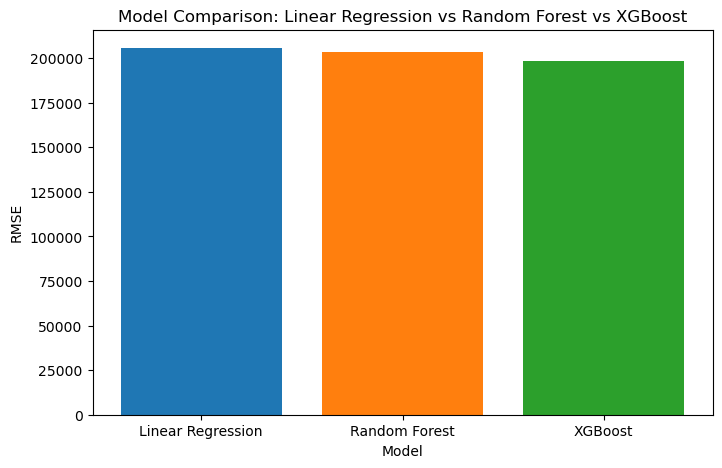

In [399]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MSE': [mean_squared_error(y_test, lr_y_pred), rfr_mse_best, xgb_mse_best],
    'RMSE': [np.sqrt(mean_squared_error(y_test, lr_y_pred)), rfr_rmse_best, xgb_rmse_best],
    'R²': [r2_score(y_test, lr_y_pred), rfr_r2_best, xgb_r2_best]
})
print(results)
plt.figure(figsize=(8, 5))
plt.bar(results['Model'], results['RMSE'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.title('Model Comparison: Linear Regression vs Random Forest vs XGBoost')
plt.savefig('model_comparison.png')
plt.show()
